In [1]:
# House Price Prediction using Regression(Linear and Polynomial regression)
# Multivariate Linear Regression
# Polynomial Regression - Degree 2
# Polynomial Regression - Degree 3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)



In [3]:
df = pd.read_csv('datasets/House_Price_data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [6]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'price_per_sqft'],
      dtype='object')

In [7]:
feature_columns = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated']

X = df[feature_columns]

Y = df["price"]

print(X.shape)
print(Y.shape)

(4600, 12)
(4600,)


In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.3,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(3220, 12)
(1380, 12)
(3220,)
(1380,)


In [9]:
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("scaler",StandardScaler()),
    ("linear_reg",LinearRegression())
])

linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [10]:
# Training

linear_model.fit(X_train,Y_train)

print("Train Done")

Train Done


In [11]:
# Test

linear_train_predictions = linear_model.predict(X_train)
linear_test_predictions = linear_model.predict(X_test)

In [12]:
linear_prediction_table = pd.DataFrame({
    "Actual":Y_test,
    "Predicted":linear_test_predictions
})

linear_prediction_table.head()

,Actual,Predicted
3683,544000.0,2.978093e+05
4411,0.0,3.165700e+05
2584,1712500.0,1.063779e+06
69,365000.0,5.467205e+05
1844,275000.0,3.702907e+05


In [13]:
def calculate_regression_metrics(y_true,y_pred,num_of_features):
  mae = mean_absolute_error(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true,y_pred)
  evs = explained_variance_score(y_true,y_pred)
  max_err = max_error(y_true,y_pred)

  metrics_dict = {
      "MAE":mae,
      "MSE":mse,
      "RMSE":rmse,
      "R2":r2,
      "EVS":evs,
      "MAX_ERR":max_err
  }

  return metrics_dict

linear_metrics = calculate_regression_metrics(Y_test,linear_test_predictions,len(feature_columns))

linear_metrics_df = pd.DataFrame(linear_metrics.items(),columns = ["Metric","Value"])

linear_metrics_df

,Metric,Value
0,MAE,1.961350e+05
1,MSE,6.793665e+11
2,RMSE,8.242369e+05
3,R2,5.963788e-02
4,EVS,6.054916e-02
5,MAX_ERR,2.639323e+07


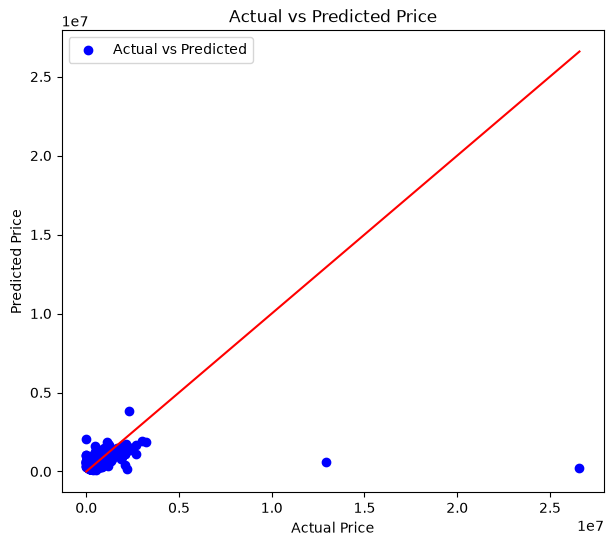

In [14]:
# Actual vs Predicted Value

plt.figure(figsize = (7,6))

plt.scatter(Y_test,linear_test_predictions,color = "blue",label = "Actual vs Predicted")
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()], color = "red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.legend()
plt.show()

In [15]:
# Polynomial Regression - Degree 2

poly_2_model = Pipeline([
    ("poly_2",PolynomialFeatures(degree = 2)),
    ("scaler",StandardScaler()),
    ("linear_reg",LinearRegression())
])

poly_2_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly_2', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
# training

poly_2_model.fit(X_train,Y_train)

print("Train Done")

poly_2_train_predictions = poly_2_model.predict(X_train)
poly_2_test_predictions = poly_2_model.predict(X_test)

poly_2_metrics = calculate_regression_metrics(Y_test,poly_2_test_predictions,len(feature_columns))

poly_2_metrics_df = pd.DataFrame(poly_2_metrics.items(),columns = ["Metric","Value"])

poly_2_metrics_df

Train Done


,Metric,Value
0,MAE,2.006572e+05
1,MSE,6.973339e+11
2,RMSE,8.350652e+05
3,R2,3.476779e-02
4,EVS,3.577233e-02
5,MAX_ERR,2.630776e+07


In [17]:
# Polynomial Regression - Degree 3

poly_3_model = Pipeline([
    ("poly_3",PolynomialFeatures(degree = 3)),
    ("scaler",StandardScaler()),
    ("linear_reg",LinearRegression())
])


poly_3_model.fit(X_train,Y_train)

print("Train Done")

poly_3_train_predictions = poly_3_model.predict(X_train)
poly_3_test_predictions = poly_3_model.predict(X_test)

poly_3_metrics = calculate_regression_metrics(Y_test,poly_3_test_predictions,len(feature_columns))

poly_3_metrics_df = pd.DataFrame(poly_3_metrics.items(),columns = ["Metric","Value"])

poly_3_metrics_df

Train Done


,Metric,Value
0,MAE,2.755503e+05
1,MSE,2.437663e+12
2,RMSE,1.561302e+06
3,R2,-2.374152e+00
4,EVS,-2.372277e+00
5,MAX_ERR,3.599836e+07


In [18]:
comparision_results = []

linear_result = {
    "Model":"Linear Regression",
    "Metrics":linear_metrics_df
}

poly_2_result = {
    "Model":"Polynomial Regression - Degree 2",
    "Metrics":poly_2_metrics_df
}

poly_3_result = {
    "Model":"Polynomial Regression - Degree 3",
    "Metrics":poly_3_metrics_df
}

comparision_results.append(linear_result)
comparision_results.append(poly_2_result)
comparision_results.append(poly_3_result)


In [19]:
rows = []
for r in comparision_results:
    metrics = r["Metrics"].set_index("Metric")["Value"]
    rows.append({"Model": r["Model"], **metrics.to_dict()})

comparison_df = pd.DataFrame(rows).set_index("Model")

In [20]:
comparison_df

,MAE,MSE,RMSE,R2,EVS,MAX_ERR
Model,,,,,,
Linear Regression,196135.029679,6.793665e+11,8.242369e+05,0.059638,0.060549,2.639323e+07
Polynomial Regression - Degree 2,200657.175017,6.973339e+11,8.350652e+05,0.034768,0.035772,2.630776e+07
Polynomial Regression - Degree 3,275550.300736,2.437663e+12,1.561302e+06,-2.374152,-2.372277,3.599836e+07


In [21]:
#logistic regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
accuracy_score,
confusion_matrix,
classification_report,
roc_curve,
roc_auc_score
)
from sklearn.datasets import (make_moons,make_circles,make_classification,make_blobs)
from sklearn.preprocessing import label_binarize

(1000, 2)
(1000,)


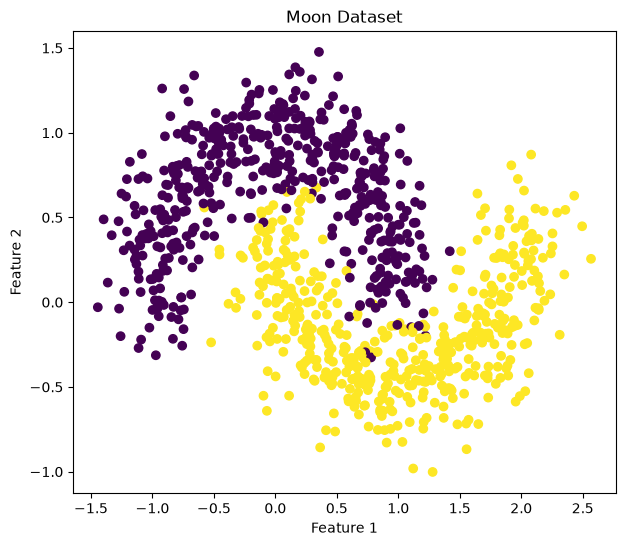

In [22]:
# Make Moon Dataset

X,y = make_moons(n_samples = 1000,noise = 0.2,random_state = 42)

print(X.shape)
print(y.shape)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moon Dataset")
plt.show()

In [23]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(800, 2)
(200, 2)
(800,)
(200,)


In [24]:
model = LogisticRegression()

model.fit(X_train,Y_train)

print("Train Done")

y_pred = model.predict(X_test)

print("Test Done")

y_prob = model.predict_proba(X_test)[:,1]

Train Done
Test Done


In [25]:
accuracy = accuracy_score(Y_test,y_pred)
conf_matrix = confusion_matrix(Y_test,y_pred)
classification_rep = classification_report(Y_test,y_pred)
roc_auc = roc_auc_score(Y_test,y_prob)

print("Accuracy : ",accuracy)
print("Confusion Matrix : \n",conf_matrix)
print("Classification Report : \n",classification_rep)
print("ROC AUC Score : ",roc_auc)

Accuracy :  0.86
Confusion Matrix : 
 [[86 14]
 [14 86]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       100
           1       0.86      0.86      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

ROC AUC Score :  0.9498


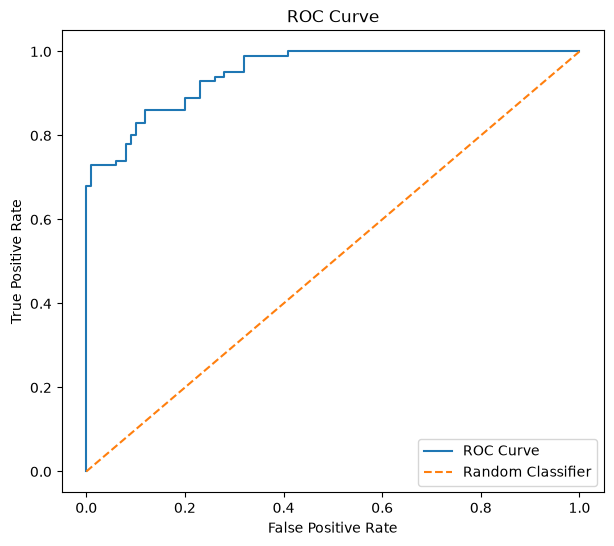

In [26]:
# ROC Curve
fpr,tpr,thresholds = roc_curve(Y_test,y_prob)

plt.figure(figsize = (7,6))
plt.plot(fpr,tpr,label = "ROC Curve")

plt.plot([0,1],[0,1],linestyle = "--",label = "Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

(2000, 2)
(2000,)


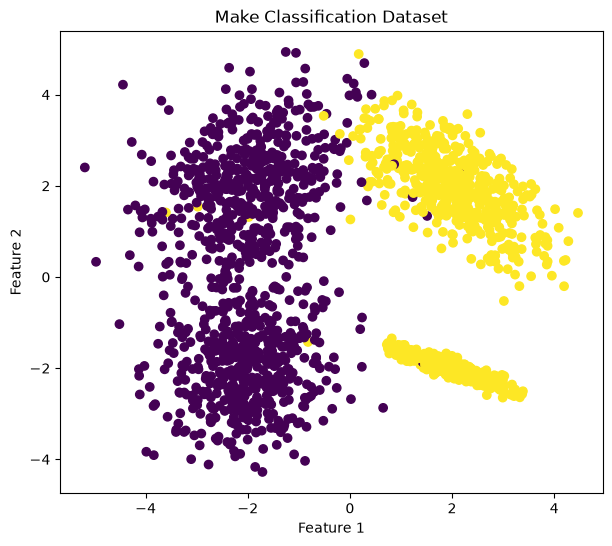

In [27]:
# Make Classifcation
X,y = make_classification(n_samples = 2000,n_features=2,
                          n_informative=2,n_redundant=0,n_classes=2,
                          n_clusters_per_class=2,class_sep=2,random_state=42)

print(X.shape)
print(y.shape)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Classification Dataset")
plt.show()

In [28]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)
model = LogisticRegression()

model.fit(X_train,Y_train)

print("Train Done")

y_pred = model.predict(X_test)

print("Test Done")

y_prob = model.predict_proba(X_test)[:,1]
accuracy = accuracy_score(Y_test,y_pred)
conf_matrix = confusion_matrix(Y_test,y_pred)
classification_rep = classification_report(Y_test,y_pred)
roc_auc = roc_auc_score(Y_test,y_prob)

print("Accuracy : ",accuracy)
print("Confusion Matrix : \n",conf_matrix)
print("Classification Report : \n",classification_rep)
print("ROC AUC Score : ",roc_auc)

(1600, 2)
(400, 2)
(1600,)
(400,)
Train Done
Test Done
Accuracy :  0.9925
Confusion Matrix : 
 [[182   0]
 [  3 215]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       182
           1       1.00      0.99      0.99       218

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

ROC AUC Score :  0.9932956951305576


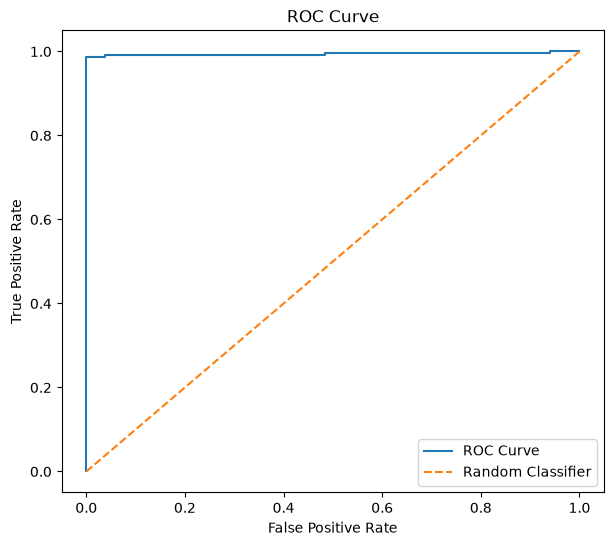

In [29]:
fpr,tpr,thresholds = roc_curve(Y_test,y_prob)

plt.figure(figsize = (7,6))
plt.plot(fpr,tpr,label = "ROC Curve")

plt.plot([0,1],[0,1],linestyle = "--",label = "Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()